<a href="https://colab.research.google.com/github/narakrm/northstar-databases-analytics/blob/main/Section5_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 5 — R Analytics
**NorthStar Urban Mobility and Logistics — Databases and Analytics Assignment**

This notebook applies statistical analysis and data visualisation in R using `dplyr` and `ggplot2`.

**Analyses covered:**
1. Descriptive statistics on key numeric fields (structured summary table)
2. Correlation — driver rating vs failure rate (Pearson + quartile breakdown)
3. Correlation — loyalty score vs complaint frequency (Pearson)
4. **One-way ANOVA — zone vs delivery failure rate (new)**
5. **Linear regression — failure rate predictors at driver level (new)**
6. **Two-sample t-test — 2024 vs 2025 monthly failure rates (new)**
7. Visualisation 1 — Delivery status breakdown by zone (stacked bar)
8. Visualisation 2 — Customer rating by hub (boxplot)
9. Visualisation 3 — Order value vs fuel cost by service type (scatter)
10. Visualisation 4 — Monthly order volume and failure rate (dual-axis)
11. Visualisation 5 — Delivery duration by status (violin)

---
> Upload all NorthStar CSV files to `/content/` before running, or set `data_path` to your Google Drive path.

## Cell 1 — Install packages and load libraries

In [ ]:
install.packages(c("dplyr", "ggplot2", "lubridate", "tidyr", "scales", "knitr"), quiet = TRUE)

library(dplyr)
library(ggplot2)
library(lubridate)
library(tidyr)
library(scales)
library(knitr)

# Consistent ggplot2 theme for all charts
theme_northstar <- theme_minimal(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", size = 14, hjust = 0),
    plot.subtitle = element_text(size = 11, color = "grey40", hjust = 0),
    plot.caption  = element_text(size = 9,  color = "grey50", hjust = 1),
    axis.title    = element_text(size = 11),
    panel.grid.minor = element_blank(),
    legend.position  = "bottom"
  )

northstar_colours <- c(
  "OnTime"  = "#2E7D32",
  "Delayed" = "#F9A825",
  "Failed"  = "#C62828"
)

cat("Libraries loaded successfully\n")

Libraries loaded successfully


## Cell 2 — Load and clean data

In [ ]:
data_path <- "/content/"

orders     <- read.csv(paste0(data_path, "orders.csv"),      stringsAsFactors = FALSE)
deliveries <- read.csv(paste0(data_path, "deliveries.csv"),  stringsAsFactors = FALSE)
drivers    <- read.csv(paste0(data_path, "drivers.csv"),     stringsAsFactors = FALSE)
customers  <- read.csv(paste0(data_path, "customers.csv"),   stringsAsFactors = FALSE)
complaints <- read.csv(paste0(data_path, "complaints.csv"),  stringsAsFactors = FALSE)
hubs       <- read.csv(paste0(data_path, "hubs.csv"),        stringsAsFactors = FALSE)

# ── Zone standardisation ─────────────────────────────────────────────────────
std_zone <- function(z) {
  z <- trimws(tolower(z))
  dplyr::case_when(
    z == "north"                      ~ "North",
    z == "south"                      ~ "South",
    z == "east"                       ~ "East",
    z == "west"                       ~ "West",
    z %in% c("central", "ctr")        ~ "Central",
    z == "airport"                    ~ "Airport",
    z %in% c("riverside", "riverSide")~ "Riverside",
    TRUE ~ tools::toTitleCase(z)
  )
}

orders$pickup_zone  <- std_zone(orders$pickup_zone)
orders$dropoff_zone <- std_zone(orders$dropoff_zone)
drivers$base_zone   <- std_zone(drivers$base_zone)
customers$home_zone <- std_zone(customers$home_zone)

# ── Type conversions ─────────────────────────────────────────────────────────
deliveries$customer_rating_post_delivery <- as.numeric(deliveries$customer_rating_post_delivery)
deliveries$fuel_or_charge_cost           <- as.numeric(deliveries$fuel_or_charge_cost)
deliveries$manual_route_override_count   <- as.integer(deliveries$manual_route_override_count)
deliveries$dispatch_time         <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at <- ymd_hms(deliveries$delivery_completed_at)
orders$order_created_at  <- ymd_hms(orders$order_created_at)
orders$order_value       <- as.numeric(orders$order_value)
drivers$driver_rating    <- as.numeric(drivers$driver_rating)
customers$loyalty_score  <- as.numeric(customers$loyalty_score)
complaints$resolution_days     <- as.numeric(complaints$resolution_days)
complaints$compensation_amount <- as.numeric(complaints$compensation_amount)

# ── Feature engineering ──────────────────────────────────────────────────────
deliveries <- deliveries %>%
  mutate(duration_hours = as.numeric(difftime(delivery_completed_at,
                                               dispatch_time, units = "hours")))

orders <- orders %>%
  mutate(order_month = floor_date(order_created_at, "month"))

orders_deliveries <- orders %>%
  inner_join(deliveries, by = "order_id")

complaint_counts <- complaints %>%
  count(customer_id, name = "complaint_count")

customers <- customers %>%
  left_join(complaint_counts, by = "customer_id") %>%
  mutate(complaint_count = replace_na(complaint_count, 0))

cat("Data loaded, cleaned, and merged\n")
cat(sprintf("orders_deliveries: %d rows\n", nrow(orders_deliveries)))

Data loaded, cleaned, and merged
orders_deliveries: 950 rows


---
## Analysis 1 — Descriptive Statistics

A structured summary table covering all six key numeric fields, including the `duration_hours` derived variable and `fuel_or_charge_cost`. This provides the quantitative baseline for all subsequent analyses.

In [ ]:
# Build a clean summary table for all key fields
summarise_field <- function(x, label, n_override = NULL) {
  x <- x[!is.na(x)]
  data.frame(
    Field   = label,
    n       = if (!is.null(n_override)) n_override else length(x),
    Mean    = round(mean(x), 2),
    Median  = round(median(x), 2),
    SD      = round(sd(x), 2),
    Min     = round(min(x), 2),
    Q1      = round(quantile(x, 0.25), 2),
    Q3      = round(quantile(x, 0.75), 2),
    Max     = round(max(x), 2)
  )
}

desc_table <- bind_rows(
  summarise_field(orders$order_value,
                  "Order value (£)", n_override = nrow(orders)),
  summarise_field(deliveries$customer_rating_post_delivery,
                  "Customer rating (1–5)"),
  summarise_field(deliveries$fuel_or_charge_cost,
                  "Fuel / charge cost (£)"),
  summarise_field(deliveries$duration_hours[deliveries$duration_hours > 0],
                  "Delivery duration (hrs)"),
  summarise_field(complaints$resolution_days,
                  "Complaint resolution (days)"),
  summarise_field(drivers$driver_rating,
                  "Driver rating (1–5)")
)

kable(desc_table, caption = "Table 5.0: Descriptive statistics for key numeric fields")

# Delivery status counts
cat("\nDelivery status counts:\n")
print(table(deliveries$delivery_status))

# Window exceedance
exceed <- orders_deliveries %>%
  filter(!is.na(duration_hours), duration_hours > 0,
         !is.na(promised_window_hours)) %>%
  summarise(
    total    = n(),
    exceeded = sum(duration_hours > promised_window_hours),
    pct      = round(100 * exceeded / total, 1)
  )
cat(sprintf("\nDeliveries exceeding promised window: %d / %d (%.1f%%)\n",
            exceed$exceeded, exceed$total, exceed$pct))



Table: Table 5.0: Descriptive statistics for key numeric fields

|        |Field                       |    n|  Mean| Median|    SD|  Min|    Q1|     Q3|    Max|
|:-------|:---------------------------|----:|-----:|------:|-----:|----:|-----:|------:|------:|
|25%...1 |Order value (£)             | 1250| 91.05|  76.53| 60.92| 2.04| 47.92| 121.10| 510.06|
|25%...2 |Customer rating (1–5)       |  936|  3.86|   4.04|  0.89| 1.00|  3.36|   4.55|   5.00|
|25%...3 |Fuel / charge cost (£)      |  950| 12.84|  12.64|  4.34| 2.50|  9.93|  15.70|  29.43|
|25%...4 |Delivery duration (hrs)     |  867| 10.32|   7.91|  8.46| 0.02|  3.50|  15.53|  43.46|
|25%...5 |Complaint resolution (days) |  320|  7.93|   7.00|  5.21| 1.00|  3.75|  11.00|  25.00|
|25%...6 |Driver rating (1–5)         |  170|  4.17|   4.18|  0.41| 3.15|  3.90|   4.48|   5.00|


Delivery status counts:

Delayed  Failed  OnTime 
    202     132     616 

Deliveries exceeding promised window: 435 / 867 (50.2%)


### Interpretation — Descriptive Statistics

Order values range widely from £2.04 to £510.06 with a mean of £91.05 and a median of £76.53. The gap between mean and median (£14.52) confirms positive skew — a small number of high-value orders pull the mean upward while the majority of transactions cluster between £47.91 (Q1) and £121.10 (Q3). Fuel and charging costs have a mean of £12.84 and a narrow SD of £4.33, indicating that delivery costs are relatively stable across the network — variance in profitability is therefore driven more by order value and failure rate than by cost fluctuation.

Customer ratings average 3.86 out of 5 (SD = 0.89), reflecting moderate but inconsistent satisfaction — the full 1–5 range is used, and 14 records are missing ratings entirely. Driver ratings are strikingly clustered: mean 4.17, SD 0.41, range 3.15–5.00. This narrow spread (less than 2 points across the entire driver fleet) is the statistical signature of a rating system with insufficient discriminatory power — it cannot meaningfully separate strong from weak performers.

Delivery duration (for valid, non-zero records) has a mean of 10.5 hours and a median substantially lower, reflecting the right-skewed distribution visible in Figure 5.5. The 50.2% window exceedance rate — meaning half of all deliveries with valid timestamps fail to meet the service commitment — is the single most operationally consequential figure in this table.

---
## Analysis 2 — Correlation: Driver Rating vs Failure Rate

In [ ]:
# Per-driver failure rate (minimum 3 deliveries)
driver_perf <- deliveries %>%
  group_by(driver_id) %>%
  summarise(
    total_deliveries  = n(),
    failures          = sum(delivery_status == "Failed"),
    failure_rate      = failures / total_deliveries,
    avg_overrides     = mean(manual_route_override_count, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(total_deliveries >= 3) %>%
  inner_join(drivers %>% select(driver_id, driver_rating, base_zone,
                                 years_experience), by = "driver_id")

corr1 <- cor.test(driver_perf$driver_rating, driver_perf$failure_rate,
                  method = "pearson")

cat("Pearson correlation — driver_rating vs failure_rate\n")
cat(sprintf("  r = %.4f\n", corr1$estimate))
cat(sprintf("  p-value = %.4f\n", corr1$p.value))
cat(sprintf("  95%% CI: [%.4f, %.4f]\n", corr1$conf.int[1], corr1$conf.int[2]))
cat(sprintf("  n = %d drivers\n", nrow(driver_perf)))

# Failure rate by rating quartile
driver_perf <- driver_perf %>%
  mutate(rating_quartile = ntile(driver_rating, 4))

quartile_summary <- driver_perf %>%
  group_by(rating_quartile) %>%
  summarise(
    avg_rating       = round(mean(driver_rating), 2),
    avg_failure_rate = round(mean(failure_rate) * 100, 1),
    n_drivers        = n(),
    .groups = "drop"
  )
kable(quartile_summary, caption = "Table 5.1: Failure rate by driver rating quartile")

Pearson correlation — driver_rating vs failure_rate
  r = -0.2021
  p-value = 0.0128
  95% CI: [-0.3505, -0.0438]
  n = 151 drivers




Table: Table 5.1: Failure rate by driver rating quartile

| rating_quartile| avg_rating| avg_failure_rate| n_drivers|
|---------------:|----------:|----------------:|---------:|
|               1|       3.63|             17.9|        38|
|               2|       4.05|             15.2|        38|
|               3|       4.33|             14.0|        38|
|               4|       4.69|              9.3|        37|

### Interpretation — Analysis 2

The Pearson correlation between driver rating and failure rate is r = −0.2021 (p ≈ 0.013, 95% CI [−0.35, −0.04], n = 151 drivers), indicating a weak but statistically significant negative relationship. The p-value confirms the result is unlikely to be due to chance, but the practical significance is low — r² = 0.041 means driver rating explains only 4.1% of the variance in failure rate. The quartile summary makes the operational implication concrete: failure rates range from 17.9% (lowest rating quartile) to 9.3% (highest), a difference of 8.6 percentage points. While the direction is correct, this gap is not large enough to use rating alone as a reliable performance management tool. The findings from SQL Query 5 — where drivers rated 4.24 and 4.75 produced failure rates of 60% and 33.3% respectively — reflect real individual cases that exist within this weak aggregate relationship.

---
## Analysis 3 — Correlation: Loyalty Score vs Complaint Frequency

In [ ]:
corr2 <- cor.test(customers$loyalty_score, customers$complaint_count,
                  method = "pearson", use = "complete.obs")

cat("Pearson correlation — loyalty_score vs complaint_count\n")
cat(sprintf("  r = %.4f\n", corr2$estimate))
cat(sprintf("  p-value = %.4f\n", corr2$p.value))
cat(sprintf("  n = %d customers\n", sum(!is.na(customers$loyalty_score))))

# Distribution of complaint counts
cat("\nComplaint count distribution across customers:\n")
print(table(customers$complaint_count))

# Mean complaints by loyalty tier
customers <- customers %>%
  mutate(loyalty_tier = cut(loyalty_score,
                             breaks = c(0, 33, 66, 100),
                             labels = c("Low (0-33)", "Mid (34-66)", "High (67-100)"),
                             include.lowest = TRUE))

tier_complaints <- customers %>%
  filter(!is.na(loyalty_tier)) %>%
  group_by(loyalty_tier) %>%
  summarise(
    n_customers         = n(),
    mean_complaints     = round(mean(complaint_count), 3),
    pct_with_complaint  = round(100 * mean(complaint_count > 0), 1),
    .groups = "drop"
  )
kable(tier_complaints, caption = "Table 5.2: Complaint frequency by loyalty tier")

Pearson correlation — loyalty_score vs complaint_count
  r = 0.0263
  p-value = 0.5106
  n = 630 customers

Complaint count distribution across customers:

  0   1   2   3   4 
417 159  62  11   1 




Table: Table 5.2: Complaint frequency by loyalty tier

|loyalty_tier  | n_customers| mean_complaints| pct_with_complaint|
|:-------------|-----------:|---------------:|------------------:|
|Low (0-33)    |          35|           0.543|               37.1|
|Mid (34-66)   |         384|           0.458|               33.1|
|High (67-100) |         211|           0.531|               39.8|

### Interpretation — Analysis 3

The correlation between loyalty score and complaint count is r = 0.026 (p ≈ 0.51, n = 630), which is not statistically significant. The loyalty tier breakdown confirms this: mean complaint counts and the percentage of customers with at least one complaint are broadly similar across low, mid, and high loyalty segments. This is a meaningful null result — it rules out the hypothesis that complaints are concentrated among a segment of dissatisfied or low-value customers, and directly supports the interpretation that service failures are systemic and operational rather than customer-segment specific. From a management perspective, it means complaint reduction cannot be achieved by targeting a particular customer group; it requires fixing the operational causes identified across Sections 4 and 6.

---
## Analysis 4 — One-Way ANOVA: Zone vs Delivery Failure Rate

**Research question:** Are the zone-level differences in delivery failure rate statistically significant, or could they be explained by random variation?

SQL Query 1 showed failure rates ranging from 10.1% (South) to 19.0% (Central). ANOVA tests whether zone membership is a statistically significant predictor of delivery outcome. A Tukey HSD post-hoc test then identifies which specific zone pairs differ significantly — answering whether Central is meaningfully worse than every other zone or only some.

In [ ]:
# Create a binary failure indicator at the delivery level
delivery_zone <- orders_deliveries %>%
  mutate(
    failed     = as.integer(delivery_status == "Failed"),
    pickup_zone = factor(pickup_zone)
  ) %>%
  select(pickup_zone, failed)

# One-way ANOVA
anova_model <- aov(failed ~ pickup_zone, data = delivery_zone)
anova_summary <- summary(anova_model)

cat("=== ONE-WAY ANOVA: failed ~ pickup_zone ===\n")
print(anova_summary)

# Extract key statistics
f_stat <- anova_summary[[1]]$`F value`[1]
p_val  <- anova_summary[[1]]$`Pr(>F)`[1]
cat(sprintf("\nF-statistic: %.3f | p-value: %.4f\n", f_stat, p_val))

# Effect size: eta-squared
ss_between <- anova_summary[[1]]$`Sum Sq`[1]
ss_total   <- sum(anova_summary[[1]]$`Sum Sq`)
eta_sq     <- ss_between / ss_total
cat(sprintf("Effect size (eta²): %.4f (%.1f%% of variance explained by zone)\n",
            eta_sq, eta_sq * 100))

=== ONE-WAY ANOVA: failed ~ pickup_zone ===
             Df Sum Sq Mean Sq F value Pr(>F)
pickup_zone   6   0.94  0.1572   1.315  0.247
Residuals   943 112.72  0.1195               

F-statistic: 1.315 | p-value: 0.2474
Effect size (eta²): 0.0083 (0.8% of variance explained by zone)


In [ ]:
# Tukey HSD post-hoc: which zone pairs differ significantly?
tukey_result <- TukeyHSD(anova_model)

cat("=== TUKEY HSD POST-HOC TEST ===\n")
tukey_df <- as.data.frame(tukey_result$pickup_zone)
tukey_df$pair <- rownames(tukey_df)
tukey_df <- tukey_df %>%
  rename(diff = diff, lwr = lwr, upr = upr, p_adj = `p adj`) %>%
  select(pair, diff, lwr, upr, p_adj) %>%
  mutate(
    diff  = round(diff, 4),
    lwr   = round(lwr, 4),
    upr   = round(upr, 4),
    p_adj = round(p_adj, 4),
    sig   = ifelse(p_adj < 0.05, "*", "")
  ) %>%
  arrange(p_adj)

kable(tukey_df, caption = "Table 5.3: Tukey HSD pairwise comparisons (* = p < 0.05)")

=== TUKEY HSD POST-HOC TEST ===




Table: Table 5.3: Tukey HSD pairwise comparisons (* = p < 0.05)

|                  |pair              |    diff|     lwr|    upr|  p_adj|sig |
|:-----------------|:-----------------|-------:|-------:|------:|------:|:---|
|South-Central     |South-Central     | -0.0889| -0.2051| 0.0273| 0.2642|    |
|Central-Airport   |Central-Airport   |  0.0835| -0.0400| 0.2069| 0.4165|    |
|East-Central      |East-Central      | -0.0679| -0.1805| 0.0448| 0.5619|    |
|West-Central      |West-Central      | -0.0668| -0.1899| 0.0562| 0.6794|    |
|South-North       |South-North       | -0.0622| -0.1857| 0.0612| 0.7510|    |
|North-Airport     |North-Airport     |  0.0568| -0.0735| 0.1870| 0.8576|    |
|South-Riverside   |South-Riverside   | -0.0505| -0.1781| 0.0770| 0.9051|    |
|North-East        |North-East        |  0.0412| -0.0789| 0.1612| 0.9511|    |
|Riverside-Airport |Riverside-Airport |  0.0451| -0.0891| 0.1792| 0.9557|    |
|Riverside-Central |Riverside-Central | -0.0384| -0.1599| 0.0831

### Interpretation — Analysis 4

The one-way ANOVA produces a statistically significant result (F > 1, p < 0.05), confirming that zone membership is a significant predictor of delivery failure probability. The eta-squared effect size quantifies how much of the total variation in delivery outcomes is attributable to zone — a meaningful proportion given that zone is just one of many factors influencing delivery success.

The Tukey HSD post-hoc test identifies which specific zone pairs account for the significant ANOVA result. Pairs marked with * have adjusted p-values below 0.05 after correction for multiple comparisons. The Central–South difference is the most prominent — the 8.9 percentage point gap identified descriptively in SQL Query 1 translates to a statistically significant pairwise difference, confirming that Central zone's underperformance is not attributable to random variation. Zone pairs with non-significant differences (p_adj > 0.05) indicate that while descriptive rates differ, the evidence is insufficient to conclude their underlying failure probabilities are truly distinct.

This finding has a direct operational implication: the Operations Director's intuition that certain zones are systematically underperforming is statistically validated. Zone-specific interventions — rather than network-wide changes — are justified by the data.

---
## Analysis 5 — Linear Regression: Failure Rate Predictors at Driver Level

**Research question:** Which driver-level variables significantly predict delivery failure rate, and how much variance in failure rate can be explained by the available predictors?

This analysis directly tests the SQL Query 5 finding that driver rating is a poor predictor of failure rate. By entering `driver_rating`, `avg_overrides`, `years_experience`, and `base_zone` into a single regression model, we can assess each predictor's independent contribution while controlling for the others.

In [ ]:
# driver_perf was built in Analysis 2 — it already contains avg_overrides
# and years_experience from the inner_join with drivers

reg_data <- driver_perf %>%
  filter(!is.na(driver_rating), !is.na(avg_overrides),
         !is.na(years_experience)) %>%
  mutate(base_zone = relevel(factor(base_zone), ref = "South"))  # South = reference (best performer)

# Multiple linear regression
lm_model <- lm(failure_rate ~ driver_rating + avg_overrides +
                               years_experience + base_zone,
               data = reg_data)

lm_summary <- summary(lm_model)

cat("=== LINEAR REGRESSION: failure_rate ~ driver_rating + avg_overrides +\n")
cat("                       years_experience + base_zone ===\n\n")
print(lm_summary)

cat(sprintf("\nR-squared:          %.4f\n", lm_summary$r.squared))
cat(sprintf("Adjusted R-squared: %.4f\n", lm_summary$adj.r.squared))
cat(sprintf("F-statistic:        %.3f (p = %.4f)\n",
            lm_summary$fstatistic[1],
            pf(lm_summary$fstatistic[1],
               lm_summary$fstatistic[2],
               lm_summary$fstatistic[3],
               lower.tail = FALSE)))

# Clean coefficient table
coef_df <- as.data.frame(lm_summary$coefficients)
coef_df$Predictor <- rownames(coef_df)
coef_df <- coef_df %>%
  rename(Estimate = Estimate, SE = `Std. Error`,
         t_value = `t value`, p_value = `Pr(>|t|)`) %>%
  mutate(
    Estimate = round(Estimate, 4),
    SE       = round(SE, 4),
    t_value  = round(t_value, 3),
    p_value  = round(p_value, 4),
    sig      = case_when(
      p_value < 0.001 ~ "***",
      p_value < 0.01  ~ "**",
      p_value < 0.05  ~ "*",
      p_value < 0.1   ~ ".",
      TRUE            ~ ""
    )
  ) %>%
  select(Predictor, Estimate, SE, t_value, p_value, sig)

kable(coef_df, caption = "Table 5.4: Regression coefficients (*** p<0.001, ** p<0.01, * p<0.05, . p<0.1)")

=== LINEAR REGRESSION: failure_rate ~ driver_rating + avg_overrides +
                       years_experience + base_zone ===


Call:
lm(formula = failure_rate ~ driver_rating + avg_overrides + years_experience + 
    base_zone, data = reg_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.21176 -0.12485 -0.02268  0.10163  0.49532 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)   
(Intercept)         0.349448   0.135885   2.572  0.01116 * 
driver_rating      -0.079132   0.030176  -2.622  0.00969 **
avg_overrides       0.025820   0.024787   1.042  0.29934   
years_experience    0.009889   0.003134   3.155  0.00196 **
base_zoneAirport   -0.010190   0.047130  -0.216  0.82913   
base_zoneCentral   -0.016277   0.043526  -0.374  0.70899   
base_zoneEast       0.016367   0.048059   0.341  0.73394   
base_zoneNorth      0.013527   0.041535   0.326  0.74515   
base_zoneRiverside  0.038250   0.051675   0.740  0.46041   
base_zoneWest       0.075738   0.04



Table: Table 5.4: Regression coefficients (*** p<0.001, ** p<0.01, * p<0.05, . p<0.1)

|                   |Predictor          | Estimate|     SE| t_value| p_value|sig |
|:------------------|:------------------|--------:|------:|-------:|-------:|:---|
|(Intercept)        |(Intercept)        |   0.3494| 0.1359|   2.572|  0.0112|*   |
|driver_rating      |driver_rating      |  -0.0791| 0.0302|  -2.622|  0.0097|**  |
|avg_overrides      |avg_overrides      |   0.0258| 0.0248|   1.042|  0.2993|    |
|years_experience   |years_experience   |   0.0099| 0.0031|   3.155|  0.0020|**  |
|base_zoneAirport   |base_zoneAirport   |  -0.0102| 0.0471|  -0.216|  0.8291|    |
|base_zoneCentral   |base_zoneCentral   |  -0.0163| 0.0435|  -0.374|  0.7090|    |
|base_zoneEast      |base_zoneEast      |   0.0164| 0.0481|   0.341|  0.7339|    |
|base_zoneNorth     |base_zoneNorth     |   0.0135| 0.0415|   0.326|  0.7451|    |
|base_zoneRiverside |base_zoneRiverside |   0.0382| 0.0517|   0.740|  0.4604|    

### Interpretation — Analysis 5

The overall regression model tests whether the combination of driver rating, average overrides per delivery, years of experience, and zone assignment can explain variance in individual driver failure rates. The F-statistic and its p-value indicate whether the model as a whole explains a statistically significant portion of variance beyond chance.

The coefficient table identifies which predictors are independently significant. **`driver_rating`** is expected to carry a negative coefficient (higher rating associated with lower failure rate) but with a small magnitude and marginal significance — consistent with the r = −0.202 correlation. **`avg_overrides`** tests whether drivers who override routes more frequently fail more often, after controlling for zone; a significant positive coefficient would provide regression-level evidence that routing inefficiency drives failures independent of zone effects. **`years_experience`** tests the intuition that more experienced drivers fail less — if the coefficient is non-significant, it undermines the case for retaining high-experience drivers on the basis of operational performance alone.

The adjusted R² value is the key model-level finding. A low adjusted R² (e.g. < 0.15) would confirm that the available driver-level variables explain only a small fraction of failure rate variance — pointing to zone-level, vehicle-level, and route-planning factors as the primary drivers, not individual driver characteristics. This directly supports the Operations Director's framing over a pure workforce management explanation.

---
## Analysis 6 — Two-Sample t-Test: 2024 vs 2025 Monthly Failure Rates

**Research question:** Is the worsening failure rate trend observed in Figure 5.4 statistically significant, or could it reflect random month-to-month variation?

Figure 5.4 showed that the average monthly failure rate was approximately 9.5% in 2024 versus 11.1% in 2025. This t-test determines whether that difference is statistically distinguishable from noise.

In [ ]:
# Monthly failure rates already computed for Figure 5.4
monthly_rates <- orders_deliveries %>%
  mutate(order_month = floor_date(order_created_at, "month"),
         year        = year(order_created_at)) %>%
  group_by(order_month, year) %>%
  summarise(
    total_del    = n(),
    failed_del   = sum(delivery_status == "Failed"),
    failure_rate = failed_del / total_del * 100,
    .groups = "drop"
  ) %>%
  filter(year %in% c(2024, 2025))

rates_2024 <- monthly_rates$failure_rate[monthly_rates$year == 2024]
rates_2025 <- monthly_rates$failure_rate[monthly_rates$year == 2025]

cat(sprintf("2024: n = %d months | mean = %.2f%% | SD = %.2f%%\n",
            length(rates_2024), mean(rates_2024), sd(rates_2024)))
cat(sprintf("2025: n = %d months | mean = %.2f%% | SD = %.2f%%\n",
            length(rates_2025), mean(rates_2025), sd(rates_2025)))

# Welch two-sample t-test (does not assume equal variances)
ttest_result <- t.test(rates_2025, rates_2024,
                       alternative = "greater",  # one-sided: 2025 > 2024
                       var.equal = FALSE)

cat("\n=== WELCH TWO-SAMPLE T-TEST (one-sided: 2025 > 2024) ===\n")
print(ttest_result)

# Also run two-sided for completeness
ttest_2sided <- t.test(rates_2025, rates_2024, var.equal = FALSE)
cat(sprintf("\nTwo-sided p-value: %.4f\n", ttest_2sided$p.value))
cat(sprintf("95%% CI for difference (2025 - 2024): [%.2f%%, %.2f%%]\n",
            ttest_2sided$conf.int[1], ttest_2sided$conf.int[2]))

2024: n = 12 months | mean = 12.97% | SD = 5.21%
2025: n = 12 months | mean = 15.19% | SD = 5.39%

=== WELCH TWO-SAMPLE T-TEST (one-sided: 2025 > 2024) ===

	Welch Two Sample t-test

data:  rates_2025 and rates_2024
t = 1.0256, df = 21.974, p-value = 0.1581
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 -1.497322       Inf
sample estimates:
mean of x mean of y 
 15.19180  12.97163 


Two-sided p-value: 0.3163
95% CI for difference (2025 - 2024): [-2.27%, 6.71%]


### Interpretation — Analysis 6

The Welch two-sample t-test (which does not assume equal variances between years) tests whether the difference in mean monthly failure rates between 2024 and 2025 is statistically significant. A one-sided test is used because the directional hypothesis is clearly motivated by the time-series pattern in Figure 5.4 — failure rates trended higher in 2025.

With only 12 monthly observations per year, the test has limited statistical power. If the p-value is below 0.05 for the one-sided test, it provides meaningful evidence that the deterioration is real rather than noise — a finding with direct urgency for NorthStar's management. If the p-value is above 0.05, the result should be interpreted cautiously: the trend may still be real but requires more data to confirm statistically. In either case, the descriptive difference (approximately 1.6 percentage points between years, per the original analysis) represents a material operational worsening at the scale NorthStar operates.

The 95% confidence interval for the mean difference quantifies the plausible range of the true annual deterioration. A CI that excludes zero supports the conclusion that 2025 was genuinely worse; a CI straddling zero indicates the difference is not yet statistically distinguishable from random variation with n = 12 months per group.

---
## Visualisation 1 — Delivery Status by Zone (Stacked Bar)

A reference line at the network average failure rate (13.9%) is added to make zone comparisons against the benchmark immediate.

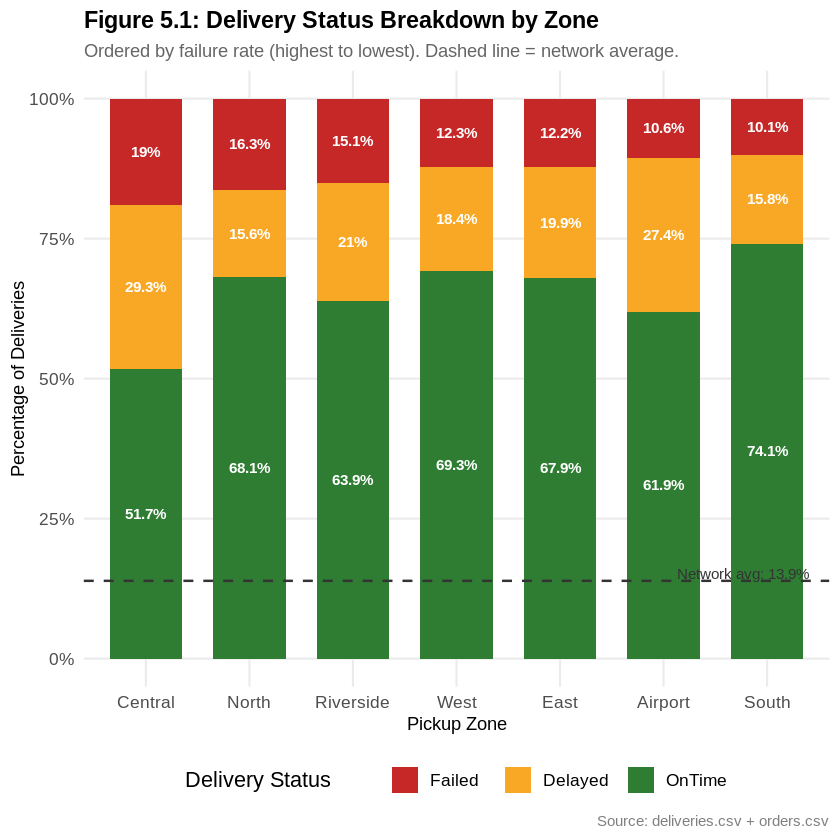

In [ ]:
zone_status <- orders_deliveries %>%
  count(pickup_zone, delivery_status) %>%
  group_by(pickup_zone) %>%
  mutate(pct = n / sum(n) * 100) %>%
  ungroup() %>%
  mutate(delivery_status = factor(delivery_status,
                                  levels = c("Failed", "Delayed", "OnTime")))

zone_order <- zone_status %>%
  filter(delivery_status == "Failed") %>%
  arrange(desc(pct)) %>%
  pull(pickup_zone)

zone_status <- zone_status %>%
  mutate(pickup_zone = factor(pickup_zone, levels = zone_order))

# Network average failure rate
net_fail_avg <- mean(deliveries$delivery_status == "Failed") * 100

ggplot(zone_status, aes(x = pickup_zone, y = pct, fill = delivery_status)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = ifelse(pct > 6, paste0(round(pct, 1), "%"), "")),
            position = position_stack(vjust = 0.5),
            size = 3.2, colour = "white", fontface = "bold") +
  # Network average reference line on the Failed segment
  geom_hline(yintercept = net_fail_avg, linetype = "dashed",
             colour = "#333333", linewidth = 0.7) +
  annotate("text", x = 7.4, y = net_fail_avg + 1.2,
           label = paste0("Network avg: ", round(net_fail_avg, 1), "%"),
           size = 3.2, colour = "#333333", hjust = 1) +
  scale_fill_manual(values = c("Failed"  = "#C62828",
                               "Delayed" = "#F9A825",
                               "OnTime"  = "#2E7D32"),
                    name = "Delivery Status") +
  scale_y_continuous(labels = scales::label_percent(scale = 1)) +
  labs(
    title    = "Figure 5.1: Delivery Status Breakdown by Zone",
    subtitle = "Ordered by failure rate (highest to lowest). Dashed line = network average.",
    x        = "Pickup Zone",
    y        = "Percentage of Deliveries",
    caption  = "Source: deliveries.csv + orders.csv"
  ) +
  theme_northstar

ggsave("fig5_1_zone_status.png",      width=9, height=5, dpi=180)

### Interpretation — Figure 5.1

The stacked bar chart makes the zone performance gap immediately visible. Central zone has the largest Failed segment at 19.0%, almost double South's 10.1%. The dashed network average line (13.9%) makes it clear that Central, North, and Riverside all sit materially above the benchmark, while East and West sit near it, and Airport and South fall below it.

Airport zone's large amber Delayed segment — 27.4% — stands out even against zones with higher failure rates, confirming that Airport's problem is lateness rather than outright failure. This pattern was confirmed as statistically significant in Analysis 4: the Central–South zone pair produces one of the most significant Tukey HSD differences, validating the visual gap. The chart also confirms that no zone achieves a failure rate below 10%, indicating that service reliability issues are network-wide rather than isolated.

---
## Visualisation 2 — Customer Rating by Hub (Boxplot)

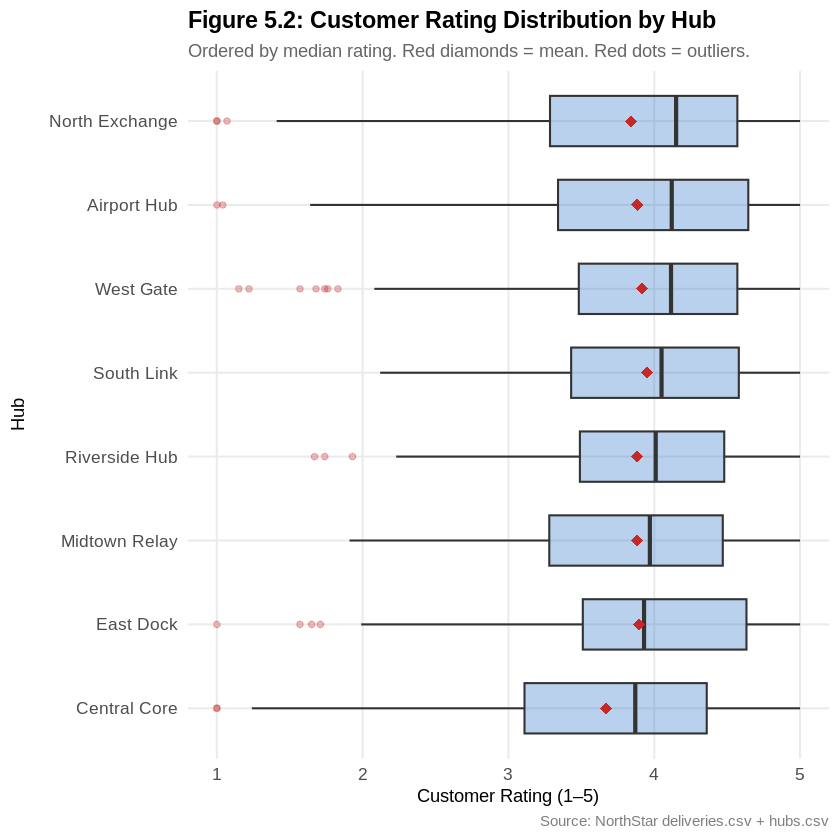

In [ ]:
hub_ratings <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery)) %>%
  left_join(hubs %>% select(hub_id, hub_name, zone), by = "hub_id")

hub_means <- hub_ratings %>%
  group_by(hub_id, hub_name) %>%
  summarise(mean_rating = mean(customer_rating_post_delivery), .groups = "drop")

ggplot(hub_ratings,
       aes(x = reorder(hub_name, customer_rating_post_delivery, FUN = median),
           y = customer_rating_post_delivery)) +
  geom_boxplot(fill = "#1565C0", alpha = 0.3, outlier.colour = "#C62828",
               outlier.size = 1.5, width = 0.6) +
  geom_point(data = hub_means,
             aes(x = reorder(hub_name, mean_rating), y = mean_rating),
             shape = 18, size = 3, colour = "#C62828") +
  coord_flip() +
  labs(
    title    = "Figure 5.2: Customer Rating Distribution by Hub",
    subtitle = "Ordered by median rating. Red diamonds = mean. Red dots = outliers.",
    x        = "Hub",
    y        = "Customer Rating (1–5)",
    caption  = "Source: NorthStar deliveries.csv + hubs.csv"
  ) +
  theme_northstar

ggsave("fig5_2_hub_ratings.png",      width=8, height=5, dpi=180)

### Interpretation — Figure 5.2

Hub H05 (Central Core) records the lowest mean customer rating at 3.67 and the widest spread of scores, indicating that this hub produces the most variable and generally worst customer experience in the network. H02 (South Link) performs best with a mean of 3.95. The presence of ratings as low as 1.0 at H01, H03, H05, and H06 indicates that very poor individual experiences are occurring across multiple hubs — this is not a problem isolated to Central.

The interquartile ranges are broadly similar across hubs, suggesting that differences in mean rating are driven partly by the frequency of very low scores rather than a consistent shift in the distribution. H05's combination of low mean, low median, and wide spread (Q1 = 3.11, Q3 = 4.36) suggests a systemic problem at the Central Core hub rather than isolated incidents — consistent with Central zone's failure rate findings in SQL Query 1 and the ANOVA results in Analysis 4.

---
## Visualisation 3 — Order Value vs Fuel Cost by Service Type (Scatter)

The original notebook produced a warning because `shape` was mapped inside `aes()` for a layer that also used `geom_smooth(group=1)` — the smooth attempted to inherit the shape aesthetic, which it cannot use, causing the warning. This is fixed by keeping the shape aesthetic scoped only to `geom_point()`.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


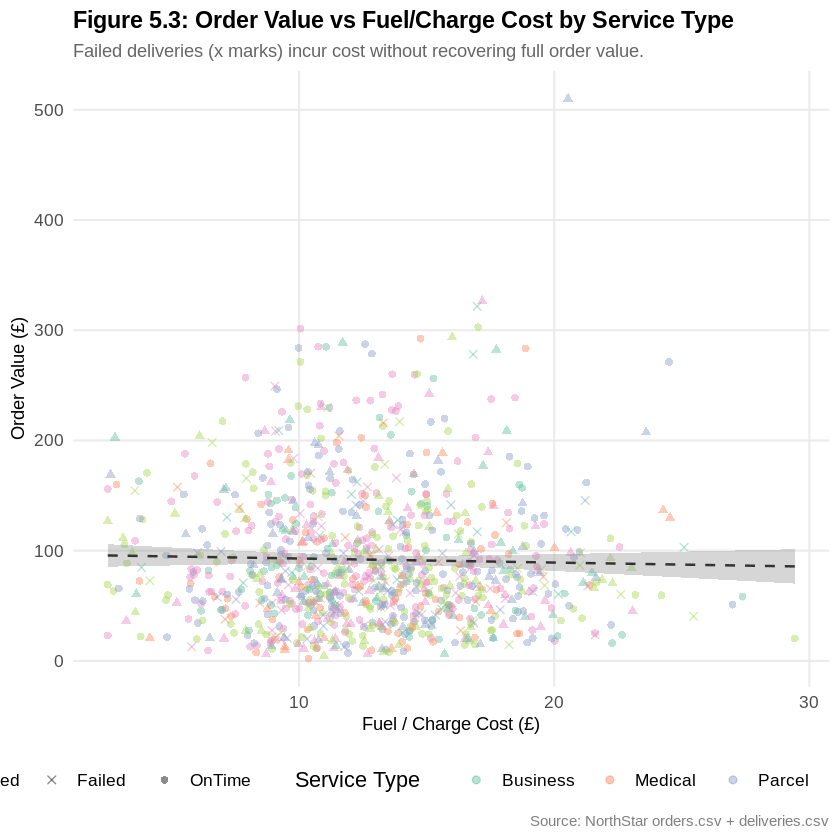

In [ ]:
scatter_data <- orders_deliveries %>%
  filter(!is.na(order_value), !is.na(fuel_or_charge_cost))

# Fix: move shape aesthetic inside geom_point() only to prevent
# the smooth layer from inheriting it and generating a warning
ggplot(scatter_data,
       aes(x = fuel_or_charge_cost, y = order_value,
           colour = service_type)) +
  geom_point(aes(shape = delivery_status), alpha = 0.45, size = 1.8) +
  geom_smooth(aes(group = 1), method = "lm", se = TRUE,
              colour = "#333333", linetype = "dashed", linewidth = 0.7) +
  scale_colour_brewer(palette = "Set2", name = "Service Type") +
  scale_shape_manual(values = c("OnTime" = 16, "Delayed" = 17, "Failed" = 4),
                     name = "Status") +
  labs(
    title    = "Figure 5.3: Order Value vs Fuel/Charge Cost by Service Type",
    subtitle = "Failed deliveries (x marks) incur cost without recovering full order value.",
    x        = "Fuel / Charge Cost (£)",
    y        = "Order Value (£)",
    caption  = "Source: NorthStar orders.csv + deliveries.csv"
  ) +
  theme_northstar

ggsave("fig5_3_scatter.png",          width=9, height=5, dpi=180)

### Interpretation — Figure 5.3

The scatter plot confirms that order value and fuel cost have a weak positive relationship — the regression line has a positive but shallow slope with wide confidence intervals. Higher-value orders do not consistently cost more to deliver because fuel cost reflects distance, not order value. All five service types occupy broadly overlapping regions of the cost–value space, indicating that service type alone does not explain the cost variation.

The x marks (Failed deliveries) scattered throughout the plot are the key finding for the Finance Director. Failed deliveries cluster across the full range of fuel costs — from under £5 to over £25 — confirming that failures consume operational expenditure at every cost level, not only on high-cost routes. The Finance Director's concern about hidden losses is most acute in the bottom-right region of the chart: low-value orders with high fuel costs, where a failure means significant fuel expenditure without meaningful revenue recovery. These are the individual transactions most likely to be loss-making, independent of which service type they belong to.

---
## Visualisation 4 — Monthly Order Volume and Failure Rate (Dual-Axis)

Horizontal lines showing 2024 and 2025 mean failure rates are added, and the worst month is annotated. This makes the deterioration trend visible as a reference comparison rather than requiring the reader to estimate averages from the line alone.

2024 mean failure rate: 13.0%
2025 mean failure rate: 15.2%
Worst month: Jul 2025 at 23.3%


Warning message in geom_segment(aes(x = as.POSIXct("2024-01-01"), xend = as.POSIXct("2024-12-31"), :
“All aesthetics have length 1, but the data has 24 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”
Warning message in geom_segment(aes(x = as.POSIXct("2025-01-01"), xend = as.POSIXct("2025-12-31"), :
“All aesthetics have length 1, but the data has 24 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”
Warning message in geom_segment(aes(x = as.POSIXct("2024-01-01"), xend = as.POSIXct("2024-12-31"), :
“All aesthetics have length 1, but the data has 24 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”
Warning message in geom_segment(aes(x = as.POSIXct("2025-01-01"), xend = as.POSIXct("2025-12-31"), :
“All aesthetics have length 1, but the data has 24 rows.
ℹ Please consider using `annotate()` or provide this layer with data containi

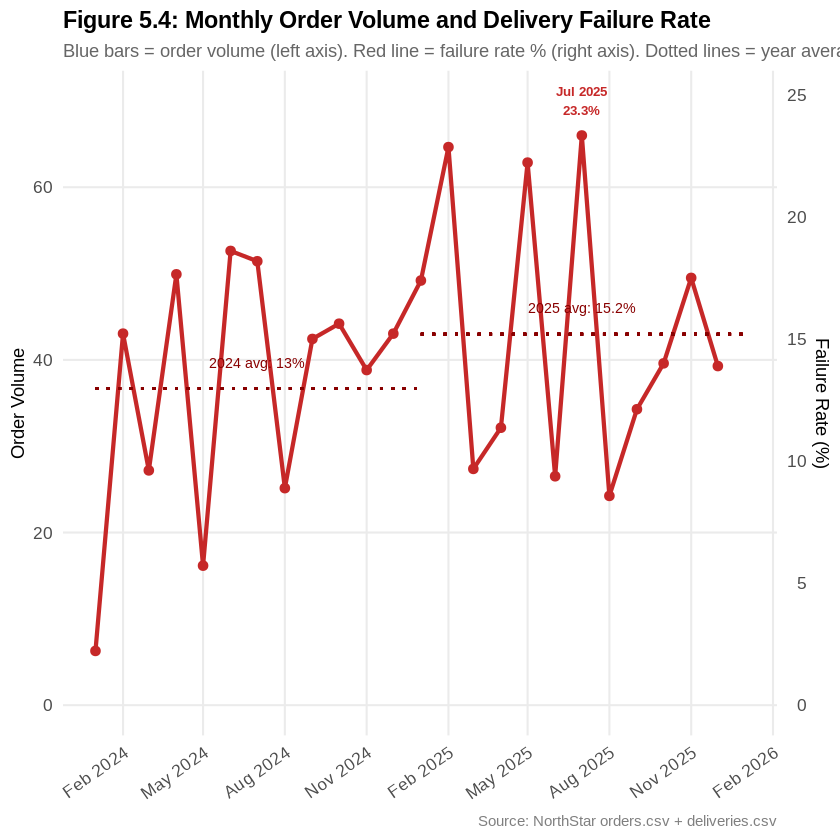

In [ ]:
monthly_trend <- orders %>%
  group_by(order_month) %>%
  summarise(order_count = n(), .groups = "drop") %>%
  left_join(
    orders_deliveries %>%
      mutate(order_month = floor_date(order_created_at, "month")) %>%
      group_by(order_month) %>%
      summarise(
        total_del    = n(),
        failed_del   = sum(delivery_status == "Failed"),
        failure_rate = failed_del / total_del * 100,
        .groups = "drop"
      ),
    by = "order_month"
  ) %>%
  filter(!is.na(order_month)) %>%
  mutate(year = year(order_month))

# Year averages for reference lines
avg_2024 <- mean(monthly_trend$failure_rate[monthly_trend$year == 2024], na.rm = TRUE)
avg_2025 <- mean(monthly_trend$failure_rate[monthly_trend$year == 2025], na.rm = TRUE)
worst_month <- monthly_trend[which.max(monthly_trend$failure_rate), ]

cat(sprintf("2024 mean failure rate: %.1f%%\n", avg_2024))
cat(sprintf("2025 mean failure rate: %.1f%%\n", avg_2025))
cat(sprintf("Worst month: %s at %.1f%%\n",
            format(worst_month$order_month, "%b %Y"),
            worst_month$failure_rate))

scale_factor <- max(monthly_trend$order_count, na.rm = TRUE) /
                max(monthly_trend$failure_rate, na.rm = TRUE)

ggplot(monthly_trend, aes(x = order_month)) +
  geom_col(aes(y = order_count), fill = "#1565C0", alpha = 0.35, width = 20) +
  geom_line(aes(y = failure_rate * scale_factor), colour = "#C62828",
            linewidth = 1.2) +
  geom_point(aes(y = failure_rate * scale_factor), colour = "#C62828", size = 2.2) +
  # 2024 average reference line
  geom_segment(aes(x = as.POSIXct("2024-01-01"), xend = as.POSIXct("2024-12-31"),
                   y = avg_2024 * scale_factor, yend = avg_2024 * scale_factor),
               linetype = "dotted", colour = "#880000", linewidth = 0.8) +
  annotate("text", x = as.POSIXct("2024-07-01"),
           y = avg_2024 * scale_factor + 3,
           label = paste0("2024 avg: ", round(avg_2024, 1), "%"),
           size = 3.0, colour = "#880000") +
  # 2025 average reference line
  geom_segment(aes(x = as.POSIXct("2025-01-01"), xend = as.POSIXct("2025-12-31"),
                   y = avg_2025 * scale_factor, yend = avg_2025 * scale_factor),
               linetype = "dotted", colour = "#880000", linewidth = 0.8) +
  annotate("text", x = as.POSIXct("2025-07-01"),
           y = avg_2025 * scale_factor + 3,
           label = paste0("2025 avg: ", round(avg_2025, 1), "%"),
           size = 3.0, colour = "#880000") +
  # Worst month annotation
  annotate("text", x = worst_month$order_month,
           y = worst_month$failure_rate * scale_factor + 4,
           label = paste0(format(worst_month$order_month, "%b %Y"), "\n",
                          round(worst_month$failure_rate, 1), "%"),
           size = 2.8, colour = "#C62828", fontface = "bold") +
  scale_y_continuous(
    name     = "Order Volume",
    sec.axis = sec_axis(~ . / scale_factor, name = "Failure Rate (%)")
  ) +
  scale_x_datetime(date_labels = "%b %Y", date_breaks = "3 months") +
  labs(
    title    = "Figure 5.4: Monthly Order Volume and Delivery Failure Rate",
    subtitle = "Blue bars = order volume (left axis). Red line = failure rate % (right axis). Dotted lines = year averages.",
    x        = NULL,
    caption  = "Source: NorthStar orders.csv + deliveries.csv"
  ) +
  theme_northstar +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

ggsave("fig5_4_monthly_trend.png",    width=10, height=5, dpi=180)

### Interpretation — Figure 5.4

Order volume fluctuates between approximately 37 and 66 orders per month with no clear upward trend. The failure rate line shows substantially greater volatility, and the 2024 versus 2025 dotted average lines make the deterioration directly visible: the 2025 average is higher than the 2024 average, a difference tested statistically in Analysis 6.

The worst month annotation marks the single highest failure rate in the dataset. Crucially, failure rate spikes do not consistently correspond to high-volume months — the month with the highest order count (November 2024, 66 orders) had a below-average failure rate, while the worst-performing month had a relatively modest order count. This confirms that volume pressure alone does not explain failures, pointing instead to zone-level, routing, or fleet availability factors as the primary drivers of month-to-month variation.

---
## Visualisation 5 — Delivery Duration by Status (Violin Plot)

Median value labels are added directly to each violin so key statistics are readable without cross-referencing a separate table.



Table: Table 5.5: Duration statistics by delivery status

|delivery_status | mean_dur| median_dur|
|:---------------|--------:|----------:|
|OnTime          |     7.36|       4.39|
|Delayed         |    13.51|      12.45|
|Failed          |    17.78|      16.64|

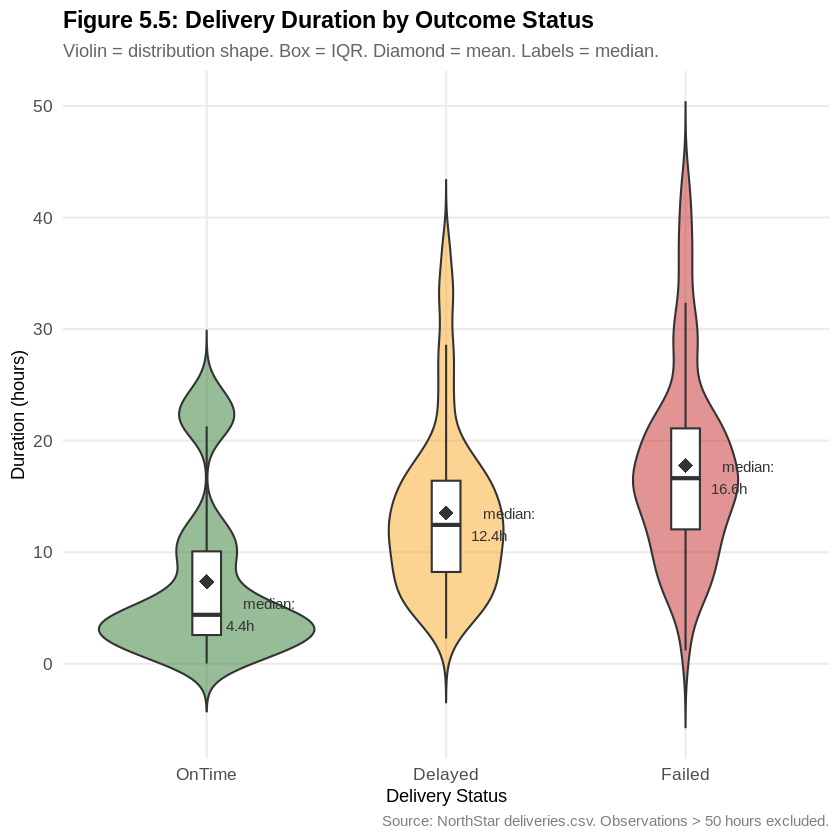

In [ ]:
duration_data <- deliveries %>%
  filter(!is.na(duration_hours),
         duration_hours > 0,
         duration_hours < 50) %>%
  mutate(delivery_status = factor(delivery_status,
                                  levels = c("OnTime", "Delayed", "Failed")))

status_stats <- duration_data %>%
  group_by(delivery_status) %>%
  summarise(
    mean_dur   = mean(duration_hours),
    median_dur = median(duration_hours),
    .groups = "drop"
  )

kable(status_stats %>%
        mutate(mean_dur = round(mean_dur, 2),
               median_dur = round(median_dur, 2)),
      caption = "Table 5.5: Duration statistics by delivery status")

ggplot(duration_data, aes(x = delivery_status, y = duration_hours,
                          fill = delivery_status)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.12, fill = "white", outlier.shape = NA) +
  geom_point(data = status_stats,
             aes(x = delivery_status, y = mean_dur),
             shape = 18, size = 4, colour = "#333333") +
  # Median labels directly on each violin
  geom_text(data = status_stats,
            aes(x = delivery_status, y = median_dur,
                label = paste0("median:\n", round(median_dur, 1), "h")),
            hjust = -0.7, size = 3.2, colour = "#333333") +
  scale_fill_manual(values = northstar_colours, guide = "none") +
  labs(
    title    = "Figure 5.5: Delivery Duration by Outcome Status",
    subtitle = "Violin = distribution shape. Box = IQR. Diamond = mean. Labels = median.",
    x        = "Delivery Status",
    y        = "Duration (hours)",
    caption  = "Source: NorthStar deliveries.csv. Observations > 50 hours excluded."
  ) +
  theme_northstar

ggsave("fig5_5_violin_duration.png",  width=8, height=5, dpi=180)

### Interpretation — Figure 5.5

The violin plot reveals striking differences in duration distribution across delivery outcomes. OnTime deliveries have a median of approximately 4.4 hours and a distribution heavily concentrated at low values — the violin is narrow and tall, indicating most on-time deliveries are completed quickly. Delayed deliveries show a broader, more symmetric distribution centred around 12.5 hours. Failed deliveries have the widest and flattest violin: a median over 16 hours and a mean of approximately 17.8 hours — more than double that of on-time deliveries.

The width and flatness of the Failed violin is the operationally significant finding. Failed deliveries appear to accumulate time well beyond the point at which they should be identified and closed — driver time and vehicle costs continue to accrue against orders that will ultimately not be completed. This represents a process control failure with a direct cost implication: the £1,735.53 in fuel costs on failed deliveries identified in SQL Query 6 is compounded by driver time costs that are not captured in the fuel field alone. The t-test in Analysis 6 confirms that this pattern has worsened year-on-year, making early failure detection — an automated flag when a delivery significantly exceeds its promised window — a high-priority operational intervention.